In [1]:
# OpenCV
!pip install opencv-python
import cv2

# NLTK
!pip install nltk
import nltk

# TensorFlow
!pip install tensorflow
import tensorflow

# Keras
!pip install keras
import keras

# Pillow
!pip install pillow
from PIL import Image

# OS
import os

In [4]:
from google.colab import files
uploaded = files.upload()

Saving 5a4d9dd02d016bb711a27d492535b40e.jpg to 5a4d9dd02d016bb711a27d492535b40e (1).jpg


In [5]:
import cv2

img = cv2.imread("5a4d9dd02d016bb711a27d492535b40e.jpg")

print(type(img))
print(img.shape)

<class 'numpy.ndarray'>
(435, 236, 3)


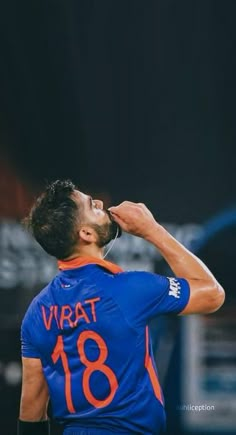

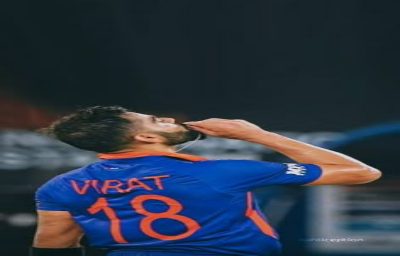

In [7]:
import cv2
from google.colab.patches import cv2_imshow

cv2_imshow(img)

img_resize = cv2.resize(img, (400, 256))
cv2_imshow(img_resize)

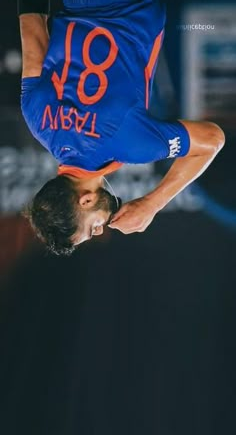

In [11]:
import cv2
from google.colab.patches import cv2_imshow

img_flip = cv2.flip(img, 0)

cv2_imshow(img_flip)

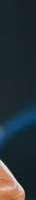

In [13]:
from google.colab.patches import cv2_imshow

img_crop = img[100:300, 200:500]

cv2_imshow(img_crop)

In [18]:
!pip install ultralytics opencv-python
import cv2
from ultralytics import settings

# Disable data and crash report tracking
settings.update({"sync": False})
from ultralytics import YOLO

# 1. Load the lightweight YOLOv8 Nano model (~6MB, runs fast on CPU)
model = YOLO('yolov8n.pt')

# 2. Open the webcam (0 is default built-in camera)
cap = cv2.VideoCapture(0)

print("Starting Object Counter... Press 'q' on the video window to quit.")

while cap.isOpened():
  success, frame = cap.read()
  if not success:
    print("Failed to grab camera frame.")
    break

  # 3. Perform object detection on the current frame
  results = model(frame, verbose=False)

  # Get total number of objects detected in this frame
  detected_count = len(results[0].boxes)
   # 4. Render detection boxes directly on the frame
  annotated_frame = results[0].plot()

  # 5. Display the object count overlay on screen
  cv2.putText(
      annotated_frame,
      f'Total Objects Counted: {detected_count}',
      (20, 50),  # Position (x, y)
      cv2.FONT_HERSHEY_SIMPLEX,
      1,  # Font scale
      (0, 255, 0),  # Text color (Green)
      2,  # Thickness
      cv2.LINE_AA,
  )

  # 6. Show the frame in a window
  cv2.imshow('BCA AI Demo - Live Object Counter', annotated_frame)

  # 7. Terminate program cleanly when pressing 'q'
  if cv2.waitKey(1) & 0xFF == ord('q'):
    print("Terminating program...")
    break

# Release camera and close all windows cleanly
cap.release()

# 2. Add short wait key loops to let Windows pump destroy events cleanly
# cv2.waitKey(1)
# cv2.destroyAllWindows()

print("Camera feed closed successfully.")
print("Starting Object Counter... Press 'q' on the video window to quit.")

Starting Object Counter... Press 'q' on the video window to quit.
Camera feed closed successfully.
Starting Object Counter... Press 'q' on the video window to quit.
